<a href="https://colab.research.google.com/github/gayathrismileyqueen4786-create/Student-Performance-Result-Analytics/blob/main/Student%20performance%20result%20analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Student Performance Report
    Name       Class  Python  Java  DBMS  English  Maths  Total  Average  \
0   Arun  III BSc CS      85    80    88       75     90    418     83.6   
1   Bala  III BSc CS      40    55    45       60     35    235     47.0   
2  Charu  III BSc CS      78    70    75       82     80    385     77.0   
3  Divya  III BSc CS      92    95    90       89     93    459     91.8   
4  Eswar  III BSc CS      35    30    40       50     28    183     36.6   

  Grade Result  
0     A   Pass  
1     F   Fail  
2     B   Pass  
3    A+   Pass  
4     F   Fail  

Topper Details
Name            Divya
Class      III BSc CS
Python             92
Java               95
DBMS               90
English            89
Maths              93
Total             459
Average          91.8
Grade              A+
Result           Pass
Name: 3, dtype: object

Weak Students
    Name  Average
1   Bala     47.0
4  Eswar     36.6

Subject Wise Average
Python     66.0
Java       66.0
DBMS     

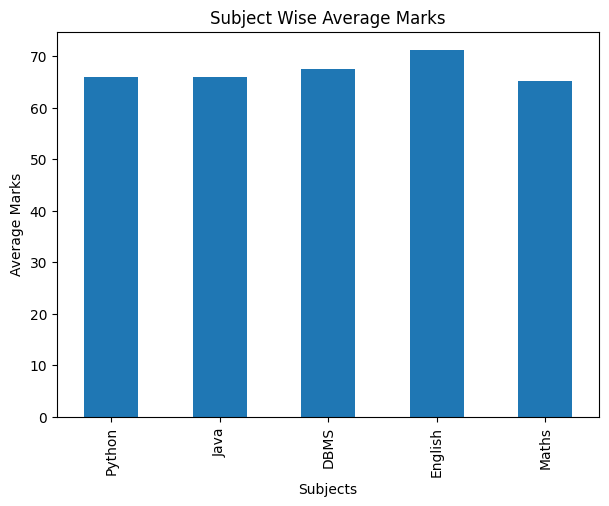

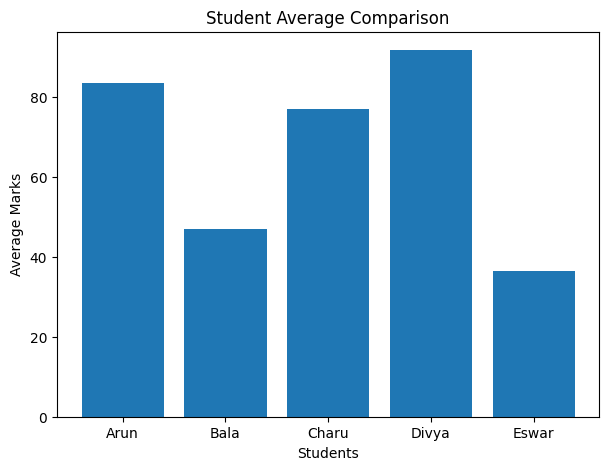

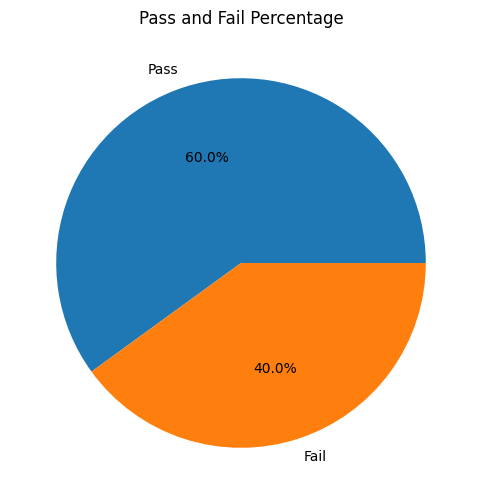

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Student Data
data = {
    "Name": ["Arun", "Bala", "Charu", "Divya", "Eswar"],
    "Class": ["III BSc CS", "III BSc CS", "III BSc CS", "III BSc CS", "III BSc CS"],
    "Python": [85, 40, 78, 92, 35],
    "Java": [80, 55, 70, 95, 30],
    "DBMS": [88, 45, 75, 90, 40],
    "English": [75, 60, 82, 89, 50],
    "Maths": [90, 35, 80, 93, 28]
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate Total and Average
subjects = ["Python", "Java", "DBMS", "English", "Maths"]

df["Total"] = df[subjects].sum(axis=1)
df["Average"] = df[subjects].mean(axis=1)

# Grade Function
def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "F"

# Pass/Fail Function
def result(row):
    for mark in row[subjects]:
        if mark < 40:
            return "Fail"
    return "Pass"

# Apply Grade and Result
df["Grade"] = df["Average"].apply(grade)
df["Result"] = df.apply(result, axis=1)

# Display Full Data
print("\nStudent Performance Report")
print(df)

# Topper
topper = df.loc[df["Average"].idxmax()]
print("\nTopper Details")
print(topper)

# Weak Students
weak_students = df[df["Average"] < 50]
print("\nWeak Students")
print(weak_students[["Name", "Average"]])

# Subject-wise Average
subject_avg = df[subjects].mean()

print("\nSubject Wise Average")
print(subject_avg)

# ---------------- Charts ---------------- #

# Subject-wise Performance
plt.figure(figsize=(7,5))
subject_avg.plot(kind='bar')
plt.title("Subject Wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()


# Student Average Comparison
plt.figure(figsize=(7,5))
plt.bar(df["Name"], df["Average"])
plt.title("Student Average Comparison")
plt.xlabel("Students")
plt.ylabel("Average Marks")
plt.show()


# Pass/Fail Pie Chart
result_count = df["Result"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(result_count,
        labels=result_count.index,
        autopct='%1.1f%%')
plt.title("Pass and Fail Percentage")
plt.show()